### 2. Generate a synthetic dataset with a small number of samples and significant noise. Train multiple Ridge models with varying 𝜆 values. Plot the Training MSE and Test MSE on the same graph. Identify the "Sweet Spot" and explain why Ordinary Least Square (𝜆 = 0) fails in this scenario.

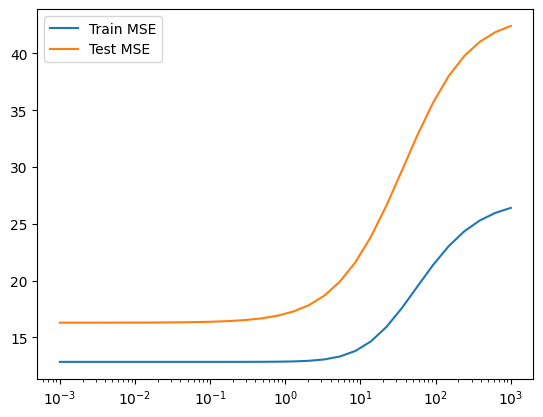

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Generate noisy dataset
X = np.random.randn(50, 10)
true_w = np.random.randn(10)
y = X @ true_w + np.random.randn(50)*5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
lambdas = np.logspace(-3, 3, 30)
train_mse = []
test_mse = []

for lam in lambdas:
    model = Ridge(alpha=lam)
    model.fit(X_train, y_train)
    
    train_mse.append(mean_squared_error(y_train, model.predict(X_train)))
    test_mse.append(mean_squared_error(y_test, model.predict(X_test)))

plt.plot(lambdas, train_mse, label="Train MSE")
plt.plot(lambdas, test_mse, label="Test MSE")
plt.xscale("log")
plt.legend()
plt.show()


Explanation

* Small λ → overfitting → low train MSE, high test MSE

* Large λ → underfitting → both MSE high

* Sweet spot → lowest test MSE

* OLS fails because it fits noise when samples are small.